In [1]:
import icechunk
import matplotlib.pyplot as plt
import pandas as pd
import zarr

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
)
from srm.utils import open_icechunk

## Get data

In [2]:
path_output = (
    "s3://us-west-2.opendata.source.coop/carbonplan/output/production/CESM2-WACCM-ERA5-global.icechunk"
    # "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
)
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
var = "tasmin"
scenario = "historical"
ens = "001"
branch = "v0.10.0"  # "qa-qc-downscaling-step/vtest01"  #  #
spatial_subset = False

In [3]:
storage = icechunk.s3_storage(
    bucket="us-west-2.opendata.source.coop",
    prefix="carbonplan/output/production/CESM2-WACCM-ERA5-global.icechunk/",
    # "srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
# print(root.tree())

{'v0.10.0', 'v0.7.0', 'main', 'v0.11.0', 'v0.8.0'}


In [4]:
def save_downscaling_improvement_csv(
    metrics_obsfine_outputfine,
    metrics_obsfine_outputcoarse,
    metrics_obscoarse_outputfine,
    metrics_obscoarse_outputcoarse,
    variable,
    scenario,
    ensemble_member,
    csv_path,
):
    diff_obsfine = (
        metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]
    )
    diff_obscoarse = (
        metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]
    )

    rows = [
        # relative to fine obs
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_downscaled_better",
            "value": float((diff_obsfine > 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_coarse_better",
            "value": float((diff_obsfine < 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_same",
            "value": float((diff_obsfine == 0).mean().values),
        },
        # relative to coarse obs
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_downscaled_better",
            "value": float((diff_obscoarse > 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_coarse_better",
            "value": float((diff_obscoarse < 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_same",
            "value": float((diff_obscoarse == 0).mean().values),
        },
        # absolute r2 values
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "mean_r2_outputfine",
            "value": float(metrics_obsfine_outputfine["r2_oneone"].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "mean_r2_outputcoarse",
            "value": float(metrics_obsfine_outputcoarse["r2_oneone"].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "mean_r2_outputfine",
            "value": float(metrics_obscoarse_outputfine["r2_oneone"].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "mean_r2_outputcoarse",
            "value": float(metrics_obscoarse_outputcoarse["r2_oneone"].mean().values),
        },
    ]

    pd.DataFrame(rows).to_csv(csv_path, mode="w", index=False)

In [5]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]

debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [6]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

if spatial_subset:
    obs_fine_subset = obs_fine.sel(lat=slice(-35, -22), lon=slice(16, 33))
    obs_fine = rechunk(obs_fine_subset, pattern="full_space").persist()

obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
).compute()

coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()
coarse_debiased_finegrid = coarse_debiased.interp(
    lon=obs_fine["lon"],
    lat=obs_fine["lat"],
    method="nearest",
).compute()

fine = rechunk(
    debiased_downscaled, pattern="full_space"
).persist()  # -> (time≈25, lat=-1, lon=-1), ~100 MB/chunk
coarsened_debiased_downscaled = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine, da_coarse_grid=coarse_debiased
)

# Compare some regridding options

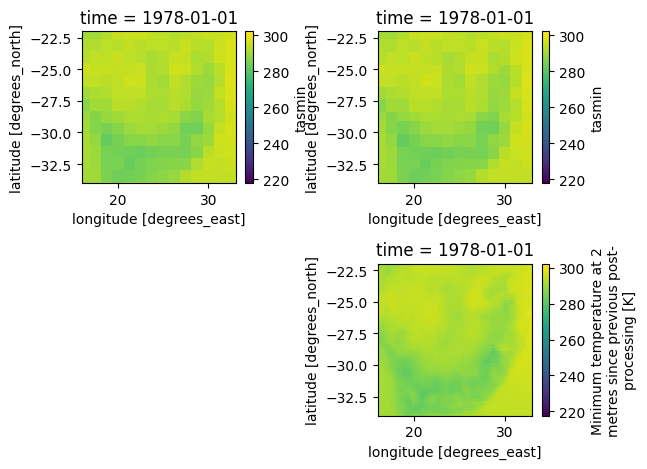

In [7]:
plt.subplot(2, 2, 1)
coarse_debiased.isel(time=0).plot()
plt.ylim([-34, -22])
plt.xlim([16, 33])

plt.subplot(2, 2, 2)
coarse_debiased_finegrid.isel(time=0).plot()
plt.ylim([-34, -22])
plt.xlim([16, 33])

plt.subplot(2, 2, 4)
debiased_downscaled.isel(time=0).plot()
plt.ylim([-34, -22])
plt.xlim([16, 33])
plt.tight_layout()

# Do evaluation

In [8]:
# Two outputs on fine grid
debiased_downscaled_doy = debiased_downscaled.groupby("time.dayofyear").mean().compute()
coarse_debiased_finegrid_doy = coarse_debiased_finegrid.groupby("time.dayofyear").mean().compute()

# Two outputs on coarse grid
coarse_debiased_doy = coarse_debiased.groupby("time.dayofyear").mean().compute()
coarsened_debiased_downscaled_doy = (
    coarsened_debiased_downscaled.groupby("time.dayofyear").mean().compute()
)

obs_fine_doy = obs_fine.groupby("time.dayofyear").mean().compute()
obs_coarse_doy = obs_coarse.groupby("time.dayofyear").mean().compute()

metrics_obsfine_outputfine = disagg_test_calculate_metrics(
    x=obs_fine_doy, y=debiased_downscaled_doy, time_dim="dayofyear"
)
metrics_obsfine_outputcoarse = disagg_test_calculate_metrics(
    x=obs_fine_doy, y=coarse_debiased_finegrid_doy, time_dim="dayofyear"
)

metrics_obscoarse_outputfine = disagg_test_calculate_metrics(
    x=obs_coarse_doy, y=coarsened_debiased_downscaled_doy, time_dim="dayofyear"
)
metrics_obscoarse_outputcoarse = disagg_test_calculate_metrics(
    x=obs_coarse_doy, y=coarse_debiased_doy, time_dim="dayofyear"
)

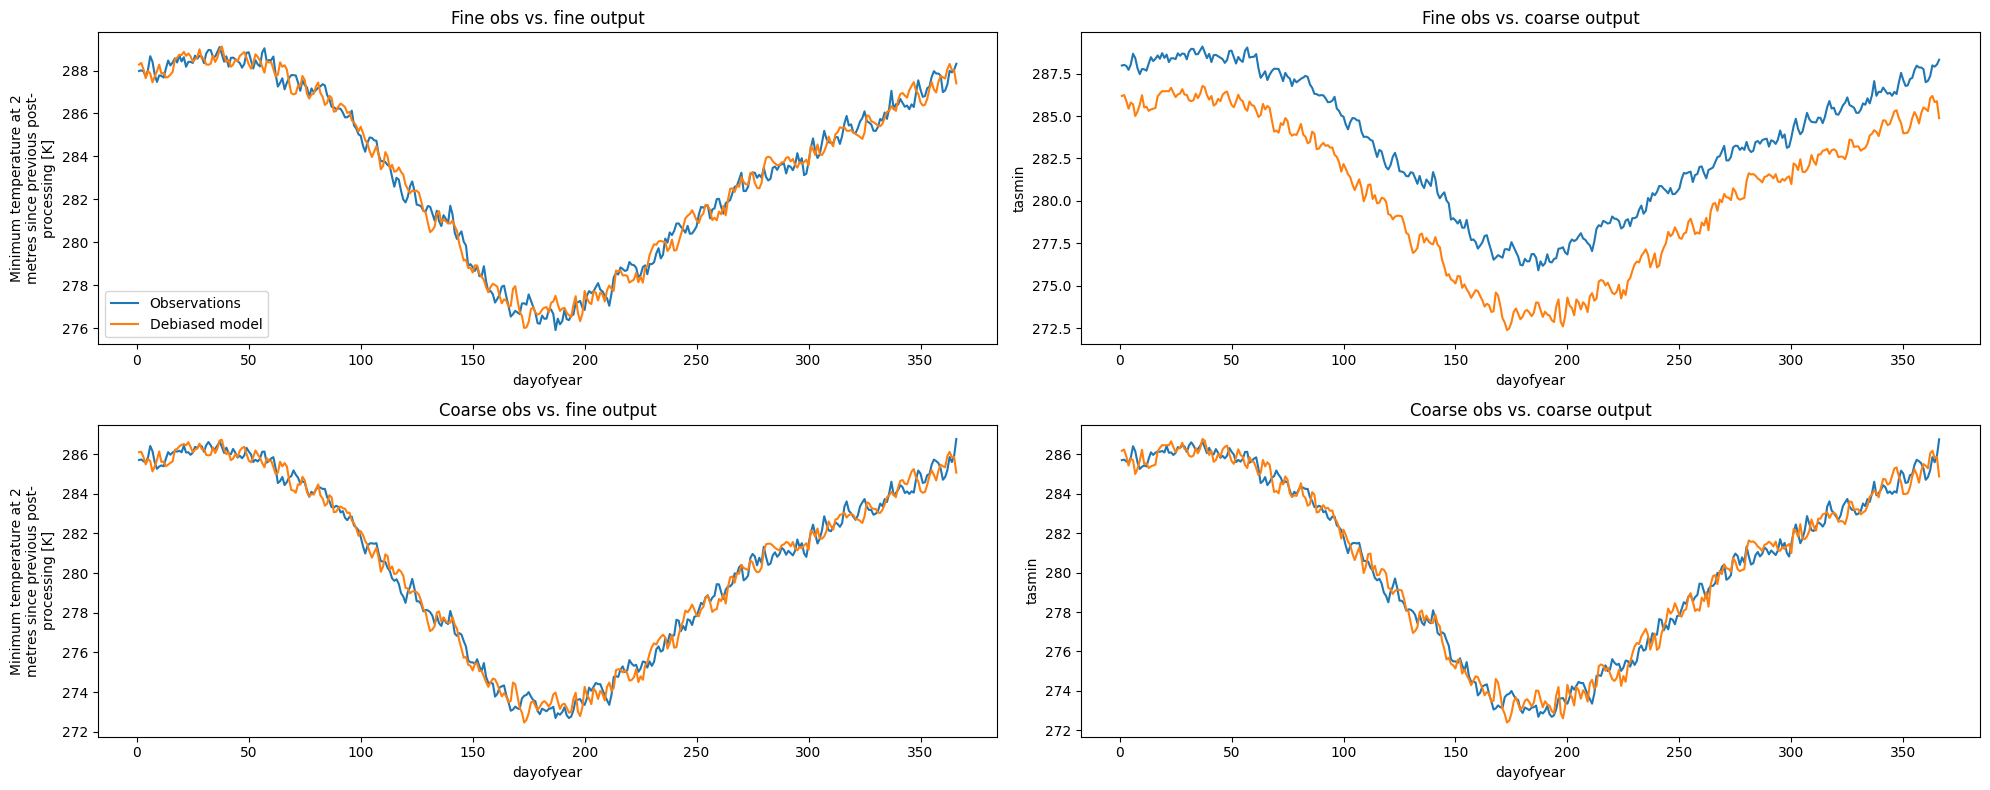

In [9]:
pt_lat = -31
pt_lon = 29
plt.figure(figsize=(20, 8))
plt.subplot(2, 2, 1)
(obs_fine_doy.sel(lat=pt_lat, lon=pt_lon).plot(label="Observations"))
(debiased_downscaled_doy.sel(lat=pt_lat, lon=pt_lon).plot(label="Debiased model"))
plt.legend()
plt.title("Fine obs vs. fine output")
plt.subplot(2, 2, 2)
(obs_fine_doy.sel(lat=pt_lat, lon=pt_lon).plot())
(coarse_debiased_finegrid_doy.sel(lat=pt_lat, lon=pt_lon).plot())
plt.title("Fine obs vs. coarse output")
plt.subplot(2, 2, 3)
(obs_coarse_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
(coarsened_debiased_downscaled_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
plt.title("Coarse obs vs. fine output")
plt.subplot(2, 2, 4)
(obs_coarse_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
(coarse_debiased_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
plt.title("Coarse obs vs. coarse output")
plt.tight_layout()

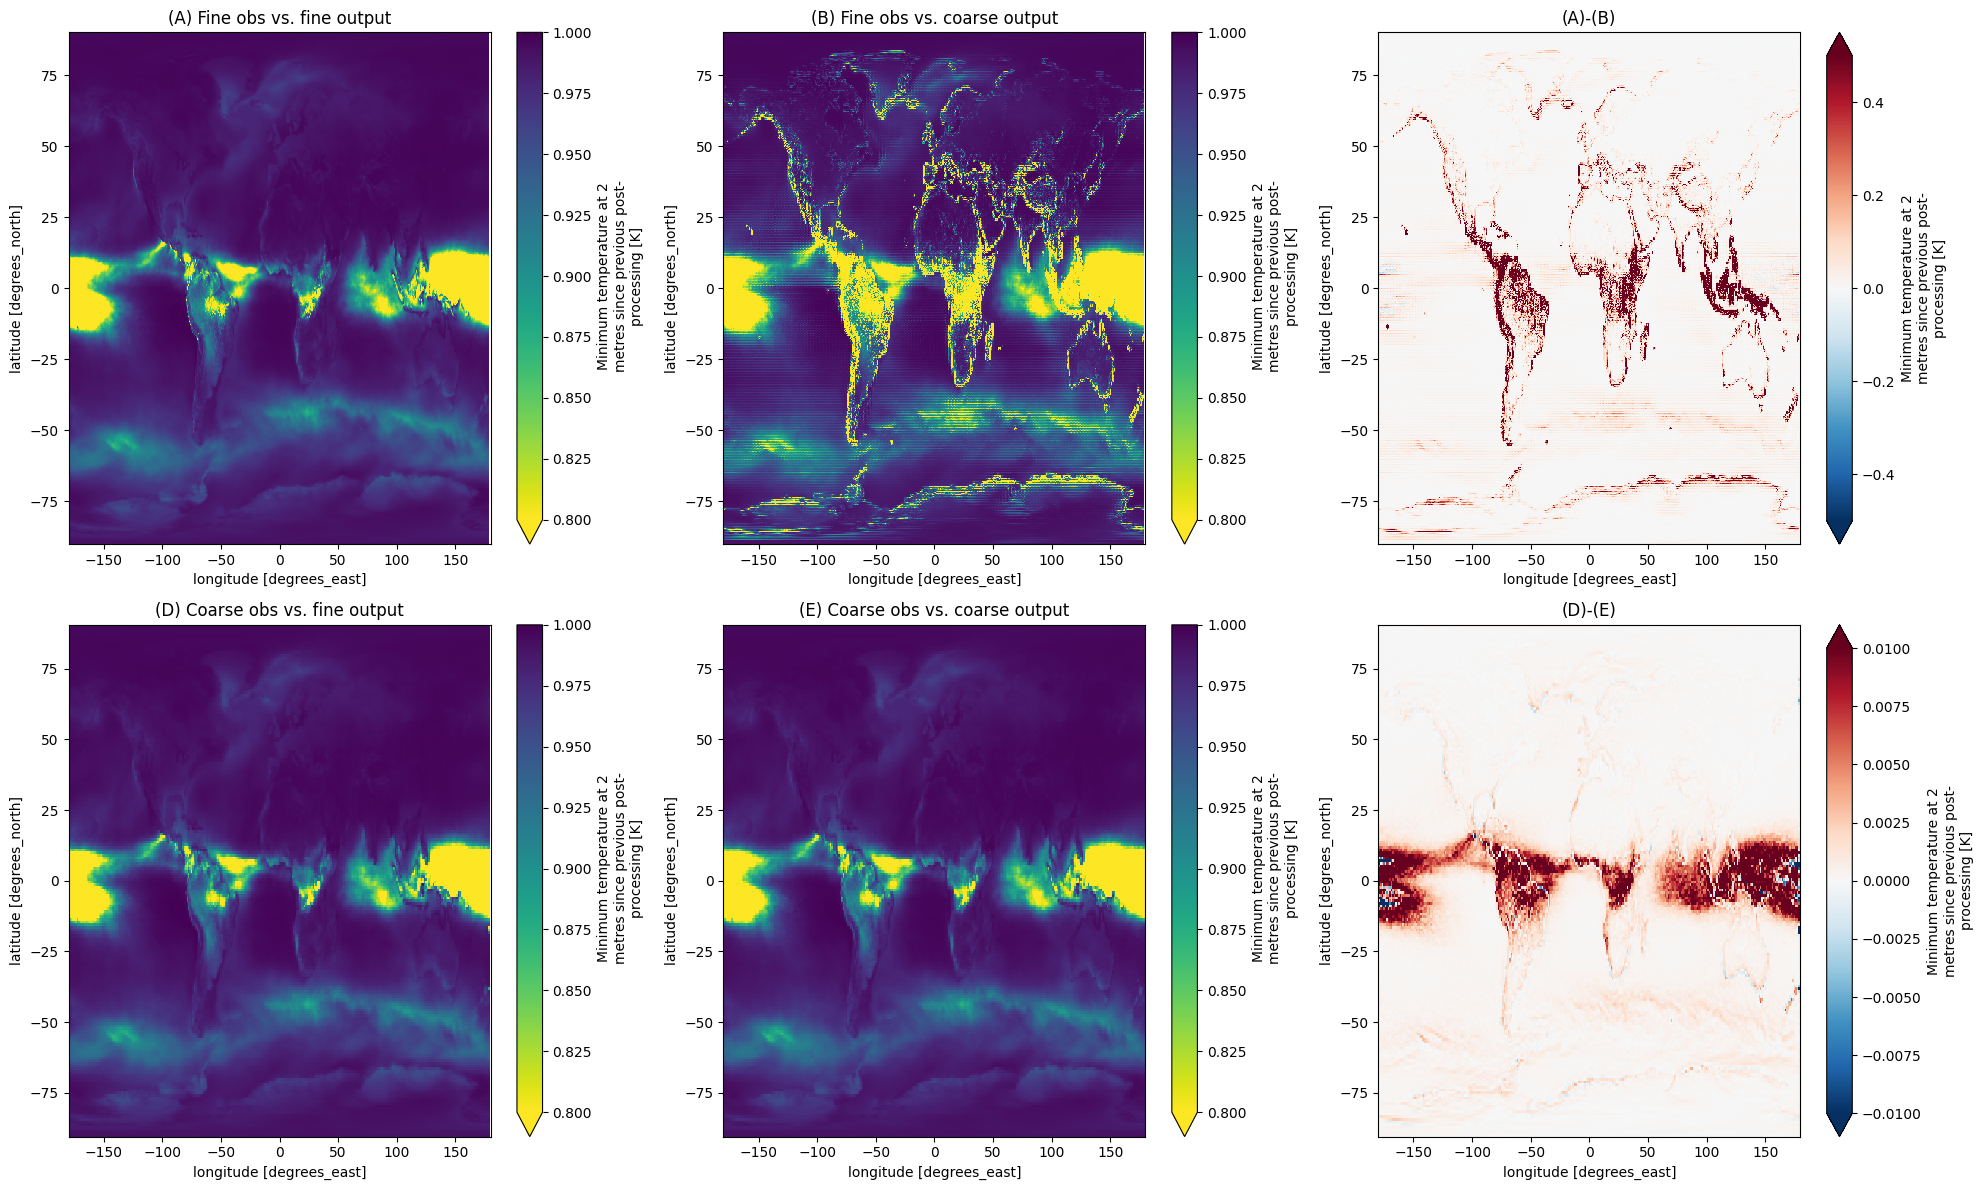

In [10]:
vmin = 0.8
vmax = 1


def format_subplot():
    # plt.ylim([-34, -22])
    # plt.xlim([17, 32])
    plt.xlim([-180, 180])


plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 1)
metrics_obsfine_outputfine["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(A) Fine obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 2)
metrics_obsfine_outputcoarse["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(B) Fine obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 3)
(metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]).plot(vmax=0.5)
plt.title("(A)-(B)")
format_subplot()
plt.subplot(2, 3, 4)
metrics_obscoarse_outputfine["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(D) Coarse obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 5)
metrics_obscoarse_outputcoarse["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(E) Coarse obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 6)
(metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]).plot(
    vmax=0.01
)
plt.title("(D)-(E)")
format_subplot()
plt.tight_layout()
plt.savefig(path_qaqc + "hist_bias_maps_" + var + "_" + scenario + "_" + ens + ".png")

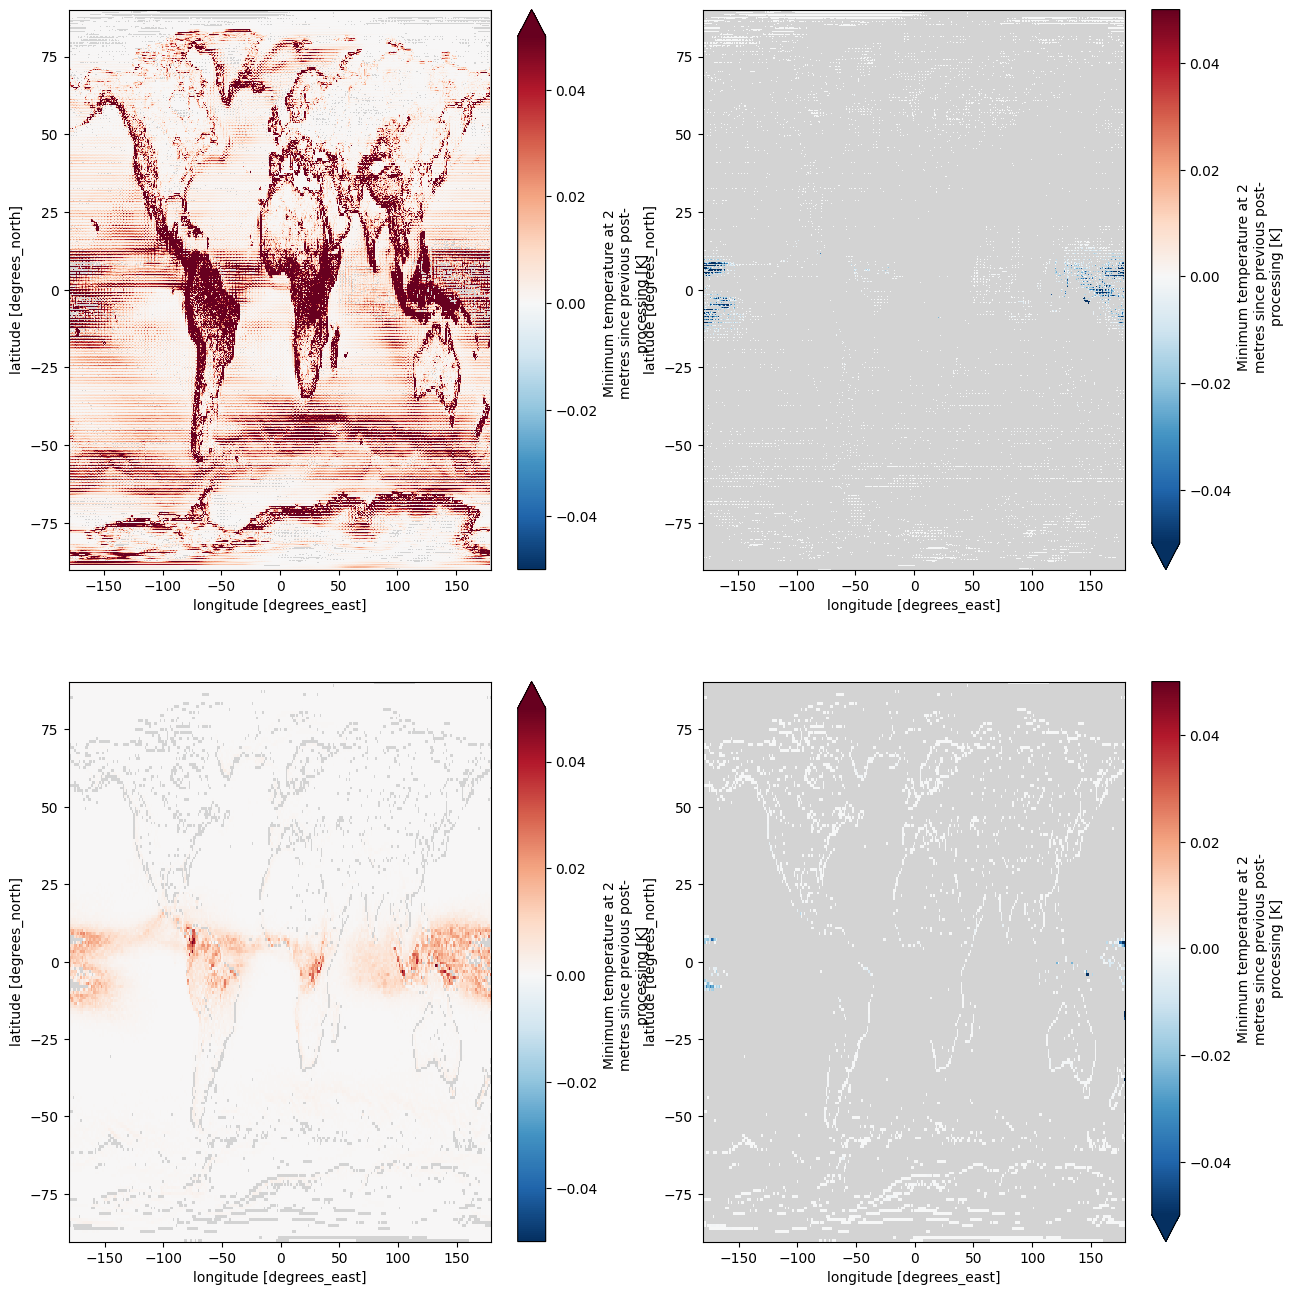

In [13]:
downcaled_vs_coarse_debiased_obsfine = (
    metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]
)
downcaled_vs_coarse_debiased_obscoarse = (
    metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]
)

plt.figure(figsize=(15, 16))
ax = plt.subplot(2, 2, 1)
ax.set_facecolor("lightgray")
(downcaled_vs_coarse_debiased_obsfine).where(downcaled_vs_coarse_debiased_obsfine > 0).plot(
    vmax=0.05, vmin=-0.05, cmap=plt.cm.RdBu_r
)
ax = plt.subplot(2, 2, 2)
(downcaled_vs_coarse_debiased_obsfine).where(downcaled_vs_coarse_debiased_obsfine < 0).plot(
    vmax=0.05, vmin=-0.05, cmap=plt.cm.RdBu_r
)
ax.set_facecolor("lightgray")
ax = plt.subplot(2, 2, 3)
ax.set_facecolor("lightgray")
(downcaled_vs_coarse_debiased_obscoarse).where(downcaled_vs_coarse_debiased_obscoarse > 0).plot(
    vmax=0.05, vmin=-0.05, cmap=plt.cm.RdBu_r
)
ax = plt.subplot(2, 2, 4)
(downcaled_vs_coarse_debiased_obscoarse).where(downcaled_vs_coarse_debiased_obscoarse < 0).plot(
    vmax=0.05, vmin=-0.05, cmap=plt.cm.RdBu_r
)
ax.set_facecolor("lightgray")

# We want the downscaled, debiased output to be better than the coarse, debiased output.

Print summary #s

In [14]:
print("Bias relative to fine-scale observations: debiased coarse vs. downscaled")
print("Fraction of area where downscaled output looks better than coarse output:")
print((downcaled_vs_coarse_debiased_obsfine > 0).mean().values)
print("Fraction of area where coarse output looks better than downscaled output:")
print((downcaled_vs_coarse_debiased_obsfine < 0).mean().values)
print("Fraction of area where coarse output looks same as downscaled output:")
print((downcaled_vs_coarse_debiased_obsfine == 0).mean().values)
print("------------------")
print("Bias relative to coarse-scale observations: debiased coarse vs. downscaled")
print("Fraction of area where downscaled output looks better than coarse output:")
print((downcaled_vs_coarse_debiased_obscoarse > 0).mean().values)
print("Fraction of area where coarse output looks better than downscaled output:")
print((downcaled_vs_coarse_debiased_obscoarse < 0).mean().values)
print("Fraction of area where coarse output looks same as downscaled output:")
print((downcaled_vs_coarse_debiased_obscoarse == 0).mean().values)
print("------------------")
print("Bias in general")
print("Fine obs vs. downscaled output")
print(metrics_obsfine_outputfine["r2_oneone"].mean().values)
print("Fine obs vs. coarse output")
print(metrics_obsfine_outputcoarse["r2_oneone"].mean().values)
print("Coarse obs vs. downscaled output")
print(metrics_obscoarse_outputfine["r2_oneone"].mean().values)
print("Coarse obs vs. coarse output")
print(metrics_obscoarse_outputcoarse["r2_oneone"].mean().values)

Bias relative to fine-scale observations: debiased coarse vs. downscaled
Fraction of area where downscaled output looks better than coarse output:
0.9591202419479119
Fraction of area where coarse output looks better than downscaled output:
0.03807404838958237
Fraction of area where coarse output looks same as downscaled output:
2.7931884728001232e-05
------------------
Bias relative to coarse-scale observations: debiased coarse vs. downscaled
Fraction of area where downscaled output looks better than coarse output:
0.9297960069444444
Fraction of area where coarse output looks better than downscaled output:
0.07011357060185185
Fraction of area where coarse output looks same as downscaled output:
9.04224537037037e-05
------------------
Bias in general
Fine obs vs. downscaled output
0.96108395
Fine obs vs. coarse output
0.5675143
Coarse obs vs. downscaled output
0.96324867
Coarse obs vs. coarse output
0.96217924


Print as csv

In [15]:
save_downscaling_improvement_csv(
    metrics_obsfine_outputfine=metrics_obsfine_outputfine,
    metrics_obsfine_outputcoarse=metrics_obsfine_outputcoarse,
    metrics_obscoarse_outputfine=metrics_obscoarse_outputfine,
    metrics_obscoarse_outputcoarse=metrics_obscoarse_outputcoarse,
    variable=var,
    scenario=scenario,
    ensemble_member=ens,
    csv_path=path_qaqc + "hist_bias_comparison_" + var + "_" + scenario + "_" + ens + ".csv",
)

# Loop through all the variables

In [20]:
var_list = ["tas", "tasmax", "tasmin"]
scenario_list = [
    "historical",
    "historical",
    "historical",
]
ens_list = ["r3i1p1f1", "001", "001"]

In [ ]:
for i, var in enumerate(var_list):
    scenario = scenario_list[i]
    ens = ens_list[i]

    print("######################################################")
    print(var)
    print(scenario)
    print(ens)
    print("######################################################")

    coarse_debiased = open_icechunk(
        path=path_output,
        branch=branch,
        group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
    )[var]

    debiased_downscaled = open_icechunk(
        path=path_output,
        branch=branch,
        group=scenario + "/" + var + "/" + ens,
    )[var]

    obs_fine = catalog.get("ERA5").to_xarray()[var]
    obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

    if spatial_subset:
        obs_fine_subset = obs_fine.sel(lat=slice(-35, -22), lon=slice(16, 33))
        obs_fine = rechunk(obs_fine_subset, pattern="full_space").persist()

    obs_coarse = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
    ).compute()

    coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()
    coarse_debiased_finegrid = coarse_debiased.interp(
        lon=obs_fine["lon"],
        lat=obs_fine["lat"],
        method="nearest",
    ).compute()

    fine = rechunk(
        debiased_downscaled, pattern="full_space"
    ).persist()  # -> (time≈25, lat=-1, lon=-1), ~100 MB/chunk
    coarsened_debiased_downscaled = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=fine, da_coarse_grid=coarse_debiased
    )

    # Two outputs on fine grid
    debiased_downscaled_doy = debiased_downscaled.groupby("time.dayofyear").mean().compute()
    coarse_debiased_finegrid_doy = (
        coarse_debiased_finegrid.groupby("time.dayofyear").mean().compute()
    )

    # Two outputs on coarse grid
    coarse_debiased_doy = coarse_debiased.groupby("time.dayofyear").mean().compute()
    coarsened_debiased_downscaled_doy = (
        coarsened_debiased_downscaled.groupby("time.dayofyear").mean().compute()
    )

    obs_fine_doy = obs_fine.groupby("time.dayofyear").mean().compute()
    obs_coarse_doy = obs_coarse.groupby("time.dayofyear").mean().compute()

    metrics_obsfine_outputfine = disagg_test_calculate_metrics(
        x=obs_fine_doy, y=debiased_downscaled_doy, time_dim="dayofyear"
    )
    metrics_obsfine_outputcoarse = disagg_test_calculate_metrics(
        x=obs_fine_doy, y=coarse_debiased_finegrid_doy, time_dim="dayofyear"
    )

    metrics_obscoarse_outputfine = disagg_test_calculate_metrics(
        x=obs_coarse_doy, y=coarsened_debiased_downscaled_doy, time_dim="dayofyear"
    )
    metrics_obscoarse_outputcoarse = disagg_test_calculate_metrics(
        x=obs_coarse_doy, y=coarse_debiased_doy, time_dim="dayofyear"
    )

    vmin = 0.8
    vmax = 1

    def format_subplot():
        # plt.ylim([-34, -22])
        # plt.xlim([17, 32])
        plt.xlim([-180, 180])

    plt.figure(figsize=(20, 12))
    plt.subplot(2, 3, 1)
    metrics_obsfine_outputfine["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
    plt.title("(A) Fine obs vs. fine output")
    format_subplot()
    plt.subplot(2, 3, 2)
    metrics_obsfine_outputcoarse["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
    plt.title("(B) Fine obs vs. coarse output")
    format_subplot()
    plt.subplot(2, 3, 3)
    (metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]).plot(
        vmax=0.5
    )
    plt.title("(A)-(B)")
    format_subplot()
    plt.subplot(2, 3, 4)
    metrics_obscoarse_outputfine["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
    plt.title("(D) Coarse obs vs. fine output")
    format_subplot()
    plt.subplot(2, 3, 5)
    metrics_obscoarse_outputcoarse["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
    plt.title("(E) Coarse obs vs. coarse output")
    format_subplot()
    plt.subplot(2, 3, 6)
    (metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]).plot(
        vmax=0.01
    )
    plt.title("(D)-(E)")
    format_subplot()
    plt.tight_layout()
    plt.savefig(path_qaqc + "hist_bias_maps_" + var + "_" + scenario + "_" + ens + ".png")

    save_downscaling_improvement_csv(
        metrics_obsfine_outputfine=metrics_obsfine_outputfine,
        metrics_obsfine_outputcoarse=metrics_obsfine_outputcoarse,
        metrics_obscoarse_outputfine=metrics_obscoarse_outputfine,
        metrics_obscoarse_outputcoarse=metrics_obscoarse_outputcoarse,
        variable=var,
        scenario=scenario,
        ensemble_member=ens,
        csv_path=path_qaqc + "hist_bias_comparison_" + var + "_" + scenario + "_" + ens + ".csv",
    )